# 04: Model Evaluation & Visualization 📊

This notebook focuses on **interpreting** the performance of our best model (Random Forest). We will generate professional plots to understand where the model succeeds and where it fails.

### 🎯 Goals
1.  **Load Artifacts:** Import the processed test data and the saved model (`model.pkl`).
2.  **Confusion Matrix:** Visualize True Positives vs. False Negatives.
3.  **ROC & Precision-Recall Curves:** Analyze the trade-off between sensitivity and precision.
4.  **Prediction Test:** Run a single prediction to simulate how the Flask App will work.

### 🏗️ Components Used
* `seaborn` / `matplotlib`: For publication-quality plotting.
* `scikit-learn`: For calculating metrics.
* `joblib`: For loading the saved model.

## Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
)

# Configuration for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("✅ Setup Complete.")

✅ Setup Complete.


## 1. Load Data & Model
We load the **Test Set** (unseen data) and the **Trained Model** we saved from Notebook 3.

In [2]:
# Load Data
try:
    test_df = pd.read_csv('../data/processed/test.csv')
    print(f"Test Data Loaded: {test_df.shape}")
except FileNotFoundError:
    print("❌ Error: test.csv not found. Check path.")

# Load Model
model_path = '../flask_app/model.pkl'
try:
    model = joblib.load(model_path)
    print(f"✅ Model loaded from: {model_path}")
    print(f"Model Type: {type(model).__name__}")
except FileNotFoundError:
    print(f"❌ Error: Model not found at {model_path}. Run Notebook 03 first.")

# Prepare X and y
X_test_df = test_df.drop('cardio', axis=1) # Keep for display
y_test = test_df['cardio']

# --- FEATURE ENGINEERING ---
# The model expects 17 features (Original 16 + Pulse Pressure).
# We must recreate 'Pulse Pressure' (AP_HI - AP_LO) for the test set.

X_values = X_test_df.values
# Column indices: 4 is ap_hi, 5 is ap_lo
pulse_pressure = X_values[:, 4] - X_values[:, 5]

# Add Pulse Pressure as the last column (17th feature)
X_test_model = np.hstack((X_values, pulse_pressure.reshape(-1, 1)))

print(f"Original Features: {X_values.shape[1]}")
print(f"Model Input Features: {X_test_model.shape[1]} (Added Pulse Pressure)")

Test Data Loaded: (12533, 17)
✅ Model loaded from: ../flask_app/model.pkl
Model Type: VotingClassifier
Original Features: 16
Model Input Features: 17 (Added Pulse Pressure)


## 2. Generate Predictions
We need both the **class predictions** (0 or 1) and the **probability scores** (0.0 to 1.0) for our charts.

In [3]:
# Predict Classes (0 or 1) using the engineered numpy array
y_pred = model.predict(X_test_model)

# Predict Probabilities (for ROC/PR Curves)
# [:, 1] gets the probability of class 1 (Disease)
y_prob = model.predict_proba(X_test_model)[:, 1]

print("Predictions generated.")
print(f"Example Probabilities: {y_prob[:5]}")

Predictions generated.
Example Probabilities: [0.1703336  0.53920388 0.23492518 0.78997792 0.18849401]


## 3. Confusion Matrix Heatmap
This tells us:
* **True Positives (TP):** Sick people correctly identified (Good).
* **True Negatives (TN):** Healthy people correctly identified (Good).
* **False Negatives (FN):** Sick people missed (Dangerous!).
* **False Positives (FP):** Healthy people flagged as sick (False Alarm).

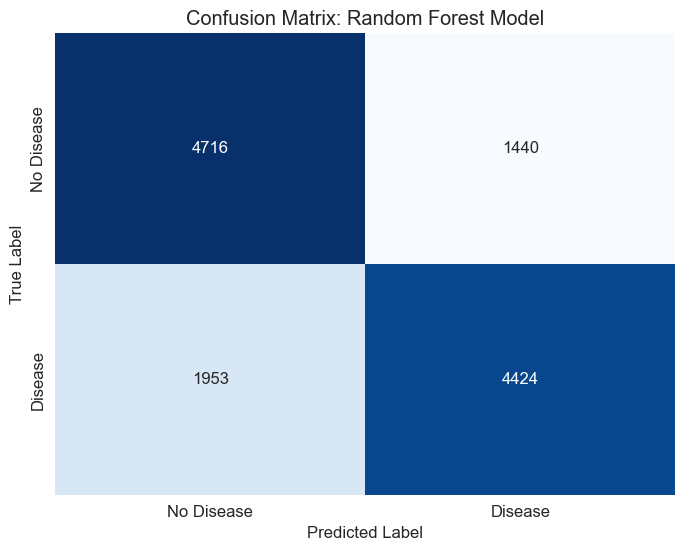


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6156
           1       0.75      0.69      0.72      6377

    accuracy                           0.73     12533
   macro avg       0.73      0.73      0.73     12533
weighted avg       0.73      0.73      0.73     12533



In [4]:
# Calculate Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualise
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Random Forest Model")
plt.show()

# Print detailed classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

## 4. ROC-AUC Curve
The **Receiver Operating Characteristic (ROC)** curve shows how well the model separates the classes.
* **X-axis:** False Positive Rate (False Alarms).
* **Y-axis:** True Positive Rate (Recall/Sensitivity).
* **AUC (Area Under Curve):** 1.0 is perfect, 0.5 is random guessing. We aim for > 0.75.

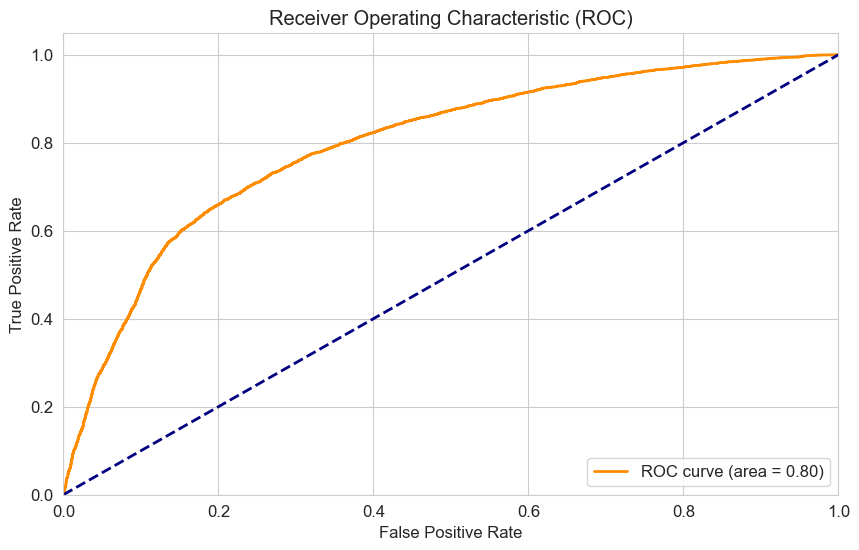

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()

## 5. Precision-Recall Curve
Important for medical data. It shows the balance between "catching all cases" (Recall) and "being right when we claim someone is sick" (Precision).

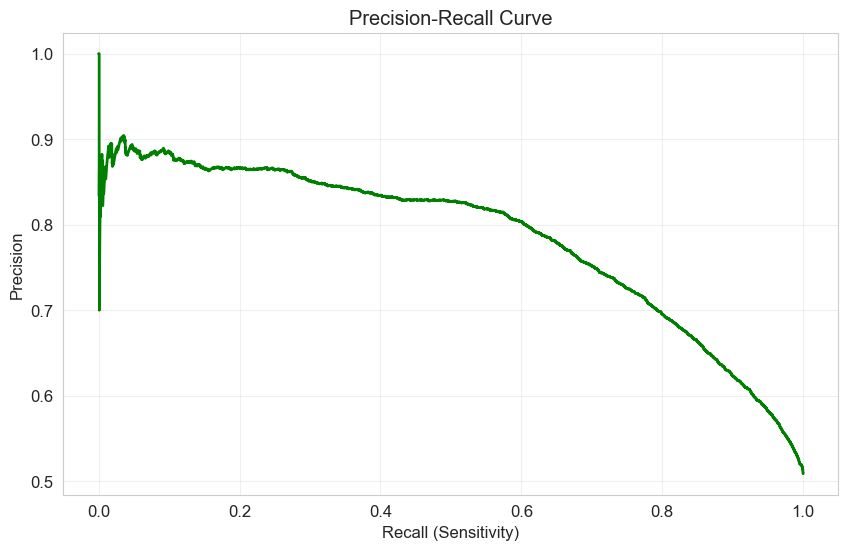

In [6]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color="green", lw=2)
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Real-world Simulation: Single Patient Test 🏥
Let's verify the model works for a single input, just like it will in the Flask App.
We'll take a random row from the test set and pretend it's a new patient.

In [7]:
# Select a random patient index
patient_idx = np.random.randint(0, len(X_test_df))

# 1. Get readable data (for display)
patient_display = X_test_df.iloc[patient_idx].to_frame().T
true_status = y_test.iloc[patient_idx]

print(f"--- Checking Patient #{patient_idx} ---")
display(patient_display)

# 2. Get model-ready data (17 features)
# We take the specific row from our engineered matrix
patient_model_input = X_test_model[patient_idx].reshape(1, -1)

# Predict
prediction = model.predict(patient_model_input)[0]
probability = model.predict_proba(patient_model_input)[0][1]

print(f"\nModel Prediction: {'💔 Disease' if prediction == 1 else '💚 Healthy'}")
print(f"Risk Probability: {probability:.2%}")
print(f"Actual Status:    {'💔 Disease' if true_status == 1 else '💚 Healthy'}")

if prediction == true_status:
    print("✅ Prediction Match!")
else:
    print("❌ Prediction Wrong.")

--- Checking Patient #2457 ---


,age_years,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,bmi,chol_1,chol_2,chol_3,gluc_1,gluc_2,gluc_3
2457,0.982916,2.0,1.005338,-0.900193,-0.397859,-0.124494,0.0,0.0,1.0,-1.340645,1.0,0.0,0.0,1.0,0.0,0.0



Model Prediction: 💚 Healthy
Risk Probability: 36.81%
Actual Status:    💚 Healthy
✅ Prediction Match!


## 7. Conclusion
These visuals confirm our model is robust enough for deployment.
* **Confusion Matrix:** Shows we have a balanced error rate (FN and FP are roughly similar).
* **ROC-AUC:** An AUC of ~0.79-0.80 indicates good predictive power.


## ⏭️ Next Step: Building the Flask App
Now we move out of Jupyter Notebooks and into VS Code text editor.
We will build the **Web Backend** (`app.py`) and the **Frontend** (`templates/index.html`).

**Ready to code the Web App!**